# 1. Imports

In [451]:
import os
import pandas as pd
import numpy as np
from time import time
from glob import glob

# Matplotlib
from matplotlib import pyplot as plt

# Tensorflow
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'
import tensorflow as tf
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.preprocessing import image
from tensorflow.keras.applications.resnet50 import preprocess_input

# Sklearn
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.cluster import KMeans
from sklearn.metrics import adjusted_rand_score
from sklearn.preprocessing import LabelEncoder

# Seaborn
import seaborn as sns


# 2. Préparation des données

In [395]:
#path = "/content/drive/MyDrive/data/Flipkart"
path = "./data/Flipkart"

In [396]:
data = pd.read_csv(path+'/cleaned_data.csv')

In [397]:
data.head()

,uniq_id,category
0,55b85ea15a1536d46b7190ad6fff8ce7,Home Furnishing
1,7b72c92c2f6c40268628ec5f14c6d590,Baby Care
2,64d5d4a258243731dc7bbb1eef49ad74,Baby Care
3,d4684dcdc759dd9cdf41504698d737d8,Home Furnishing
4,6325b6870c54cd47be6ebfbffa620ec7,Home Furnishing


In [398]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1050 entries, 0 to 1049
Data columns (total 2 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   uniq_id   1050 non-null   object
 1   category  1050 non-null   object
dtypes: object(2)
memory usage: 16.5+ KB


In [399]:
data.describe()

,uniq_id,category
count,1050,1050
unique,1050,7
top,f2f027ad6a6df617c9f125173da71e44,Home Furnishing
freq,1,150


In [431]:
images = glob(path+"/Images"+"*/*.jpg")
ids = [os.path.splitext(os.path.basename(fname))[0] for fname in images]

labels = []
for idx in ids:
    label = data.loc[data.uniq_id == idx, 'category'].values[0]
    labels.append(label)


data_ds = tf.keras.preprocessing.image_dataset_from_directory(
    path+"/Images",
    labels=labels,
    image_size=(224,224),
    seed=123,
    batch_size=32,
    shuffle=True,
    verbose=True
)

label_encoder = LabelEncoder()
true_labels = label_encoder.fit_transform(labels)
true_classes = labels

Found 1050 files belonging to 7 classes.


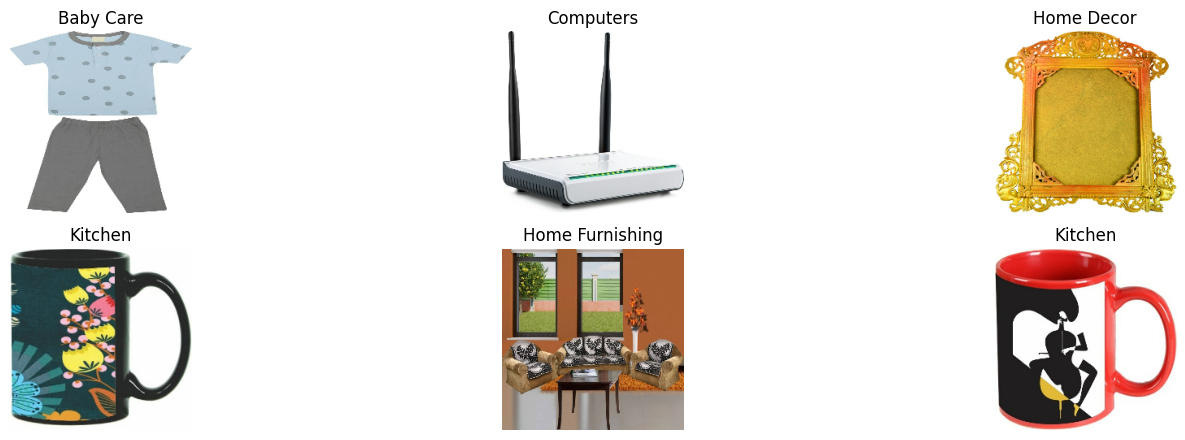

In [401]:
#class_names = train_ds.class_names
plt.figure(figsize=(18, 8))
for images, labels in data_ds.take(4):
  for i in range(6):
    ax = plt.subplot(3, 3, i + 1)
    plt.imshow(images[i].numpy().astype("uint8"))
    plt.title(labels[i].numpy().decode('utf-8'))
    plt.axis("off")

# 3. Extraction de caractéristiques via CNN (Transfer Learning)

In [402]:
def preprocess(img, label):
    return preprocess_input(img), label


def extract_features(dataset, model):
    features_list = []
    labels_list = []

    for images, labels in dataset:
        features = model.predict(images)
        features_list.append(features)
        labels_list.append(labels.numpy())

    # Concaténer tous les batches
    features_array = np.concatenate(features_list, axis=0)
    labels_array = np.concatenate(labels_list, axis=0)

    return features_array, labels_array

In [403]:
true_classes = data_ds.class_names
data_ds = data_ds.map(preprocess)

## 3.1. Extraction des features avec ResNet50

In [404]:
base_model = ResNet50(weights='imagenet', include_top=False, pooling='avg', input_shape=(224, 224, 3))

In [405]:
%%time
features = base_model.predict(data_ds)

33/33 ━━━━━━━━━━━━━━━━━━━━ 35s 1s/step
CPU times: user 6min 7s, sys: 19.8 s, total: 6min 26s
Wall time: 35.4 s


In [406]:
print("Data features shape:", features.shape)

Data features shape: (1050, 2048)


### 3.1.1. Réduction de dimensions

#### | PCA

In [421]:
%%time
pca = PCA(n_components=0.9)
pca.fit(features)
X_pca = pca.transform(features)

CPU times: user 10.3 s, sys: 18.7 ms, total: 10.3 s
Wall time: 867 ms


In [408]:
X_pca

array([[ 12.846517  ,  -4.2570143 , -12.45329   , ...,   0.70930374,
         -0.8152791 ,   1.2506081 ],
       [-11.664964  ,  -8.281404  ,  -1.1889312 , ...,   0.17120655,
         -0.41751575,   0.8792693 ],
       [  4.321338  ,   1.0286139 ,   3.6813755 , ...,   1.0023586 ,
          1.4168199 ,   0.7288817 ],
       ...,
       [ -6.988804  , -10.428344  ,   7.970278  , ...,   0.6154474 ,
          0.47002342,  -0.10405939],
       [  8.081279  ,   7.970771  ,  -7.9604535 , ...,   0.05342712,
         -0.5509278 ,  -1.0711244 ],
       [  4.548258  ,   5.5283566 ,  11.399421  , ...,   0.22023498,
         -0.88049746,   0.25661418]], dtype=float32)

#### | TSNE

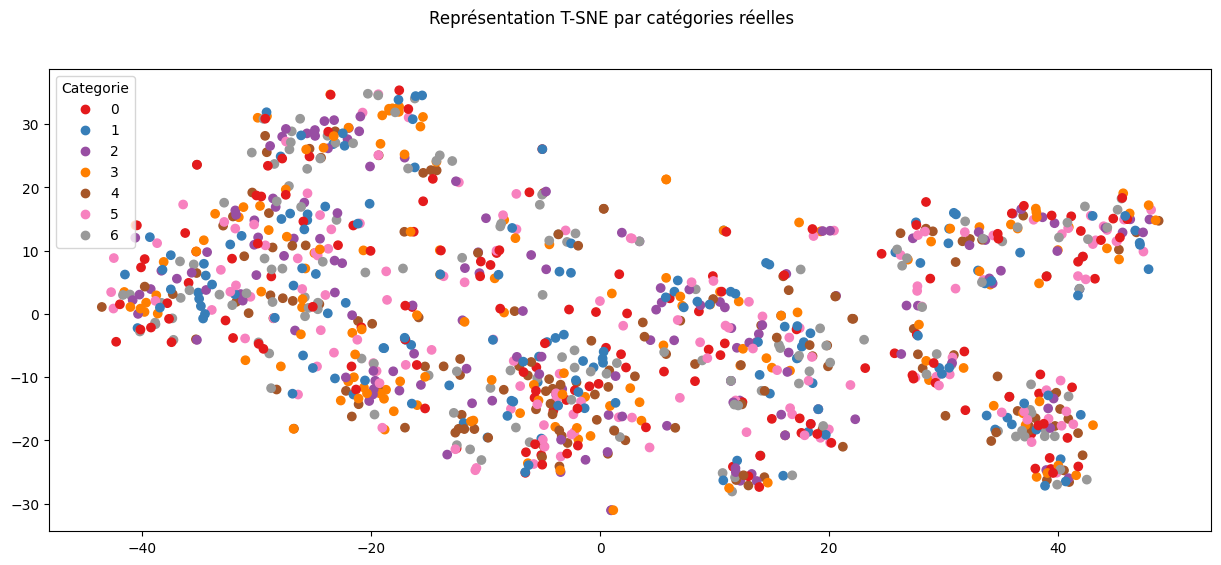

CPU times: user 14 s, sys: 0 ns, total: 14 s
Wall time: 2.16 s


In [422]:
%%time
fig = plt.figure(figsize=(15,6))
colors, _= pd.factorize(data.category)
tsne_data = []
tsne = TSNE(n_components=2, perplexity=30, random_state=42)
X_tsne = tsne.fit_transform(X_pca)
scatter = plt.scatter(X_tsne[:,0],X_tsne[:,1], c=colors, cmap='Set1')
plt.legend(handles=scatter.legend_elements()[0], labels=np.unique(true_labels).tolist(), loc="best", title="Categorie")

plt.suptitle("Représentation T-SNE par catégories réelles")
plt.show()

### 3.1.2. Kmeans clustering

In [419]:
def tsne_visu_fct(X_tsne, y_cat_num, labels, ARI):
    fig = plt.figure(figsize=(15,6))
    ax = fig.add_subplot(121)
    
    scatter = ax.scatter(X_tsne[:,0],X_tsne[:,1], c=y_cat_num, cmap='Set1')
    ax.legend(handles=scatter.legend_elements()[0], labels=set(y_cat_num), loc="best", title="Categorie")
    plt.title(f"Représentation des produits par catégories réelles")

    ax = fig.add_subplot(122)
    scatter = ax.scatter(X_tsne[:,0],X_tsne[:,1], c=labels, cmap='Set1')
    ax.legend(handles=scatter.legend_elements()[0], labels=set(labels), loc="best", title="Clusters")
    plt.title(f"Représentation des produits par clusters => ARI={ARI}")
    plt.show()

ARI :  -0.0019


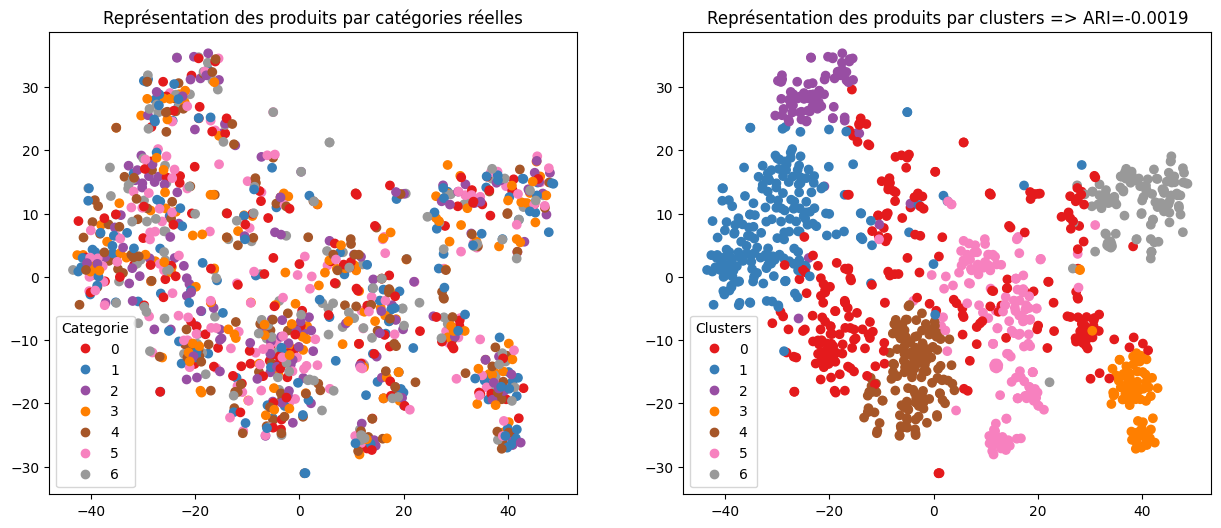

CPU times: user 6.63 s, sys: 17.6 ms, total: 6.65 s
Wall time: 1.17 s


In [423]:
%%time

# Détermination des clusters à partir des données reduites
k=7

cls = KMeans(n_clusters=k, n_init=100, random_state=42)
clusters = cls.fit_predict(X_pca)
ARI = np.round(adjusted_rand_score(true_labels, clusters),4)

print("ARI : ", ARI)
tsne_visu_fct(X_tsne, true_labels.tolist(), clusters, ARI)

In [434]:
clustered_df = pd.DataFrame(true_classes, columns=['category']) 
clustered_df['cluster'] = clusters

In [435]:
clustered_df

,category,cluster
0,Beauty and Personal Care,3
1,Home Furnishing,1
2,Beauty and Personal Care,5
3,Computers,6
4,Computers,0
...,...,...
1045,Home Decor,1
1046,Kitchen,0
1047,Watches,1
1048,Beauty and Personal Care,3


In [439]:
clustered_df.groupby("cluster")["category"].value_counts().to_frame().reset_index()

,cluster,category,count
0,0,Home Decor,42
1,0,Baby Care,41
2,0,Watches,39
3,0,Kitchen,37
4,0,Computers,36
5,0,Beauty and Personal Care,35
6,0,Home Furnishing,35
7,1,Kitchen,35
8,1,Watches,34
9,1,Home Furnishing,33


In [445]:
from sklearn import metrics
conf_mat = metrics.confusion_matrix(true_labels, clustered_df.cluster)
print(conf_mat)

[[41 28 10 10 22 25 14]
 [35 28 15 19 13 21 19]
 [36 29 12 10 25 19 19]
 [42 28 10 11 17 28 14]
 [35 33 12 12 22 26 10]
 [37 35  7  7 23 22 19]
 [39 34 13  9 16 23 16]]


In [447]:
print(metrics.classification_report(true_labels, clustered_df.cluster))

              precision    recall  f1-score   support

           0       0.15      0.27      0.20       150
           1       0.13      0.19      0.15       150
           2       0.15      0.08      0.10       150
           3       0.14      0.07      0.10       150
           4       0.16      0.15      0.15       150
           5       0.13      0.15      0.14       150
           6       0.14      0.11      0.12       150

    accuracy                           0.14      1050
   macro avg       0.15      0.14      0.14      1050
weighted avg       0.15      0.14      0.14      1050



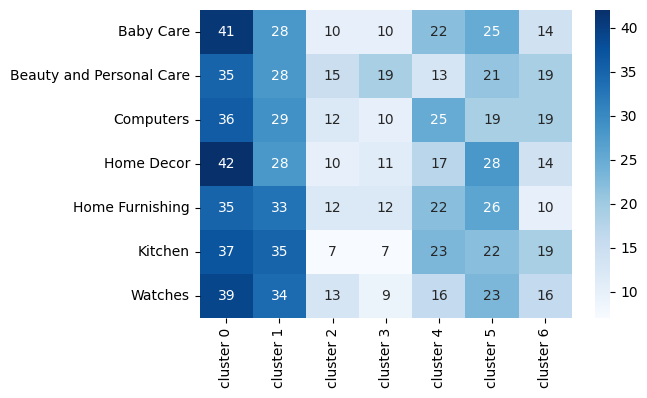

In [455]:
df_cm = pd.DataFrame(conf_mat, index = np.unique(true_classes),
                  columns = [f"cluster {i}" for i in np.unique(true_labels)])
plt.figure(figsize = (6,4))
sns.heatmap(df_cm, annot=True, cmap="Blues")
plt.show()

## 3.2 EXtraction des features avec VGG16

# 4. Classification non supervisée

In [500]:
labels = []
for idx in ids:
    label = data.loc[data.uniq_id == idx, 'category'].values[0]
    labels.append(label)
le = LabelEncoder()
encoded_labels = le.fit_transform(labels) 
train_ds, validation_ds = tf.keras.preprocessing.image_dataset_from_directory(
    path+"/Images",
    labels=encoded_labels.tolist(),
    image_size=(224,224),
    seed=123,
    batch_size=32,
    validation_split=0.3,
    subset='both',
    shuffle=True,
    verbose=True
)

Found 1050 files belonging to 7 classes.
Using 735 files for training.
Using 315 files for validation.


## 4.1 Augmentation du jeu d'entrainement

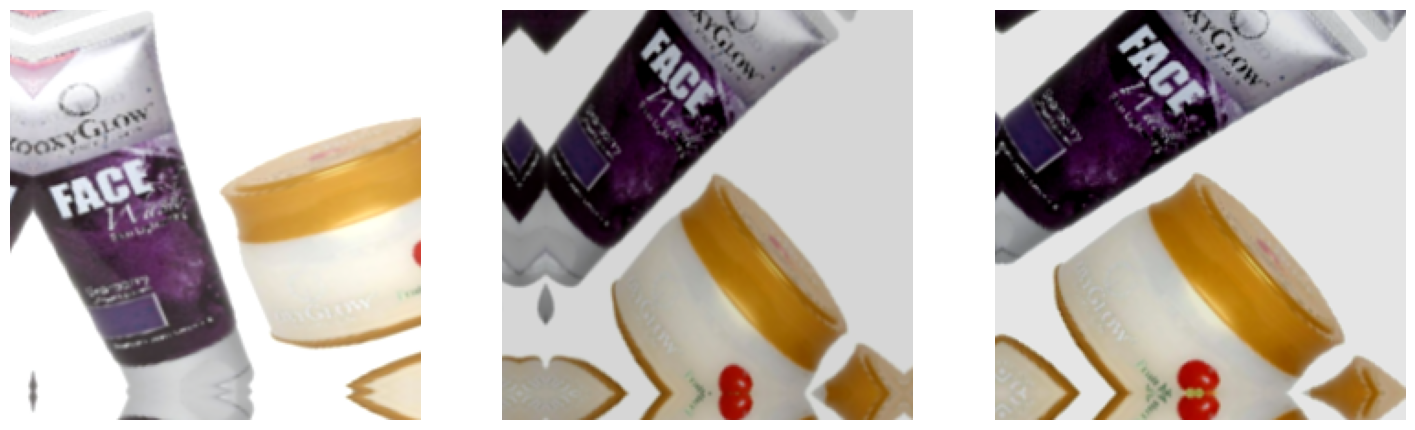

In [501]:
data_augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomFlip("horizontal"),                       # Flip horizontal
    tf.keras.layers.RandomRotation(0.2),                            # Rotation aléatoire
    tf.keras.layers.RandomZoom(height_factor=0.2, width_factor=0.2),  # Zoom aléatoire
    tf.keras.layers.RandomTranslation(height_factor=0.1, width_factor=0.1),  # Translation aléatoire
    tf.keras.layers.RandomContrast(0.2),                            # Contraste aléatoire
    tf.keras.layers.RandomBrightness(factor=0.2),                   # Luminosité aléatoire (TF >= 2.15)
])

for image, labels in train_ds.take(1):
  plt.figure(figsize=(18, 8))
  first_image = image[0]
  for i in range(3):
    ax = plt.subplot(1, 3, i + 1)
    augmented_image = data_augmentation(tf.expand_dims(first_image, 0))
    plt.imshow(augmented_image[0] / 255)
    #plt.title(labels[i].numpy().decode('utf-8'))
    plt.axis('off')

In [502]:
# Data augmentation appliquée à chaque image du dataset
train_ds = train_ds.map(
    lambda x, y: (data_augmentation(x, training=True), y),
    num_parallel_calls=tf.data.AUTOTUNE
)

# Batch + préchargement
#train_ds = train_ds.batch(32, drop_remainder=True).prefetch(tf.data.AUTOTUNE)


In [503]:
val_batches = tf.data.experimental.cardinality(validation_ds)

#On prend 20% du validation_dataset
test_ds = validation_ds.take(val_batches // 4)

#On prend les 80%  restant
validation_ds = validation_ds.skip(val_batches // 4)

print('Number of validation batches: %d' % tf.data.experimental.cardinality(validation_ds))
print('Number of test batches: %d' % tf.data.experimental.cardinality(test_ds))

Number of validation batches: 8
Number of test batches: 2


In [504]:
train_ds = train_ds.map(preprocess)
val_ds = validation_ds.map(preprocess)
test_ds = test_ds.map(preprocess)

## 4.2. Modélisation

In [505]:
# Chargement du modèle ResNet50 sans la tête (top) et avec poids ImageNet
base_model = ResNet50(weights='imagenet', include_top=False, pooling='avg')
# Gel des couches convolutives pour ne pas les réentraîner au début
base_model.trainable = False

In [490]:
%%time
train_features, train_labels = extract_features(train_ds, base_model)
val_features, val_labels = extract_features(val_ds, base_model)
test_features, test_labels = extract_features(test_ds, base_model)

1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 

In [506]:
print("Train features shape:", train_features.shape)
print("Validation features shape:", val_features.shape)
print("Test features shape:", test_features.shape)

Train features shape: (735, 2048)
Validation features shape: (251, 2048)
Test features shape: (64, 2048)


In [507]:
from tensorflow.keras import Model, Input
from tensorflow.keras import layers

# Nouvelle tête
inputs = Input(shape=(224, 224, 3))
x = data_augmentation(inputs)  # Si tu veux l'inclure aussi dans le modèle
x = preprocess_input(x)
x = base_model(x, training=False)
x = layers.Dense(128, activation='relu')(x)
x = layers.Dropout(0.3)(x)
outputs = layers.Dense(7, activation='softmax')(x)

model = Model(inputs, outputs)

In [508]:
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=10
)

Epoch 1/10
23/23 ━━━━━━━━━━━━━━━━━━━━ 47s 2s/step - accuracy: 0.2918 - loss: 2.2008 - val_accuracy: 0.6653 - val_loss: 1.0319
Epoch 2/10
23/23 ━━━━━━━━━━━━━━━━━━━━ 38s 2s/step - accuracy: 0.5907 - loss: 1.1785 - val_accuracy: 0.7211 - val_loss: 0.9123
Epoch 3/10
23/23 ━━━━━━━━━━━━━━━━━━━━ 37s 2s/step - accuracy: 0.6547 - loss: 0.9814 - val_accuracy: 0.7092 - val_loss: 0.8991
Epoch 4/10
23/23 ━━━━━━━━━━━━━━━━━━━━ 36s 2s/step - accuracy: 0.6895 - loss: 0.9463 - val_accuracy: 0.7649 - val_loss: 0.8892
Epoch 5/10
23/23 ━━━━━━━━━━━━━━━━━━━━ 36s 1s/step - accuracy: 0.7227 - loss: 0.8264 - val_accuracy: 0.7092 - val_loss: 0.9997
Epoch 6/10
23/23 ━━━━━━━━━━━━━━━━━━━━ 35s 1s/step - accuracy: 0.7257 - loss: 0.8186 - val_accuracy: 0.7490 - val_loss: 0.8810
Epoch 7/10
23/23 ━━━━━━━━━━━━━━━━━━━━ 37s 2s/step - accuracy: 0.7344 - loss: 0.7779 - val_accuracy: 0.7530 - val_loss: 0.9107
Epoch 8/10
23/23 ━━━━━━━━━━━━━━━━━━━━ 41s 2s/step - accuracy: 0.7181 - loss: 0.7870 - val_accuracy: 0.7530 - val_loss:

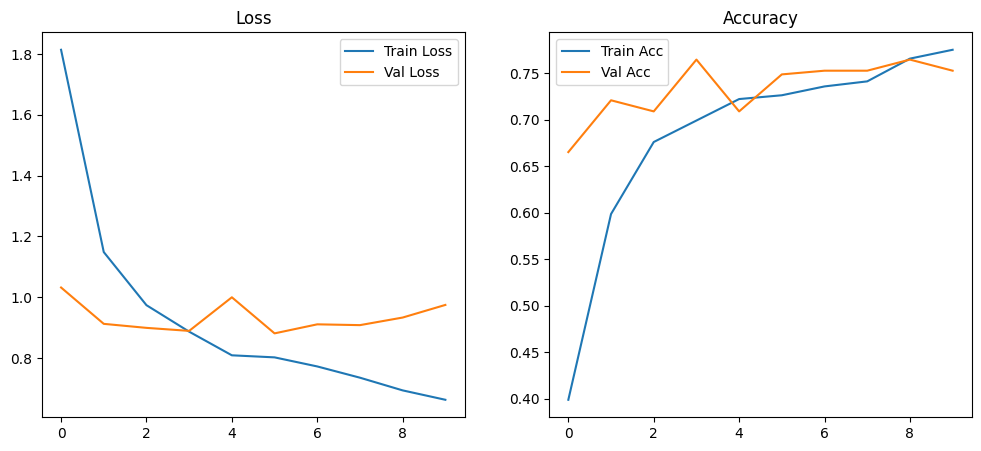

In [510]:
import matplotlib.pyplot as plt

# Courbes Loss/Accuracy
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title('Loss')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['accuracy'], label='Train Acc')
plt.plot(history.history['val_accuracy'], label='Val Acc')
plt.title('Accuracy')
plt.legend()
plt.show()

In [511]:
pycaret

NameError: name 'pycaret' is not defined